# MNIST Autoencoder

Training a convolutional autoencoder to reconstruct MNIST digits with PyTorch Lightning.

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['retina', 'svg']
%load_ext autoreload
%autoreload 2

import os

import matplotlib.pyplot as plt
import torch
from lightning import Trainer
from torchinfo import summary

from chimera.data import MNISTDataModule
from chimera.modules import AutoencoderModule
from chimera.optim import LinearWarmupCosineAnnealingLR

os.environ["DATA_DIR"] = "../../../data"

## Data

Load MNIST without normalization so pixels stay in `[0, 1]`, matching the decoder's sigmoid output.

In [2]:
dm = MNISTDataModule(
    pin_memory=False, num_workers=4, data_dir=os.environ["DATA_DIR"], image_size=32
)
dm.prepare_data()
dm.setup("fit")

train_loader = dm.train_dataloader()
val_loader = dm.val_dataloader()

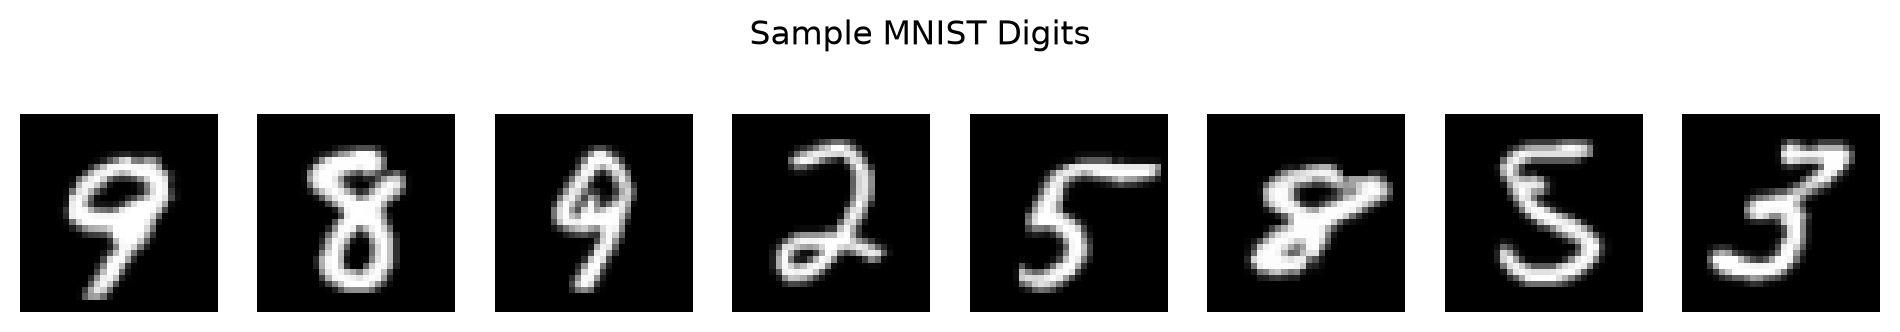

In [3]:
images, _ = next(iter(train_loader))

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
fig.suptitle("Sample MNIST Digits")
for ax, img in zip(axes, images):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.axis("off")
plt.show()

## Model

A convolutional autoencoder: the encoder compresses each 28x28 image to a latent vector, and the decoder reconstructs it.

In [4]:
from chimera.models import DigitDreamerAE

model = DigitDreamerAE(in_channels=1, latent_dim=2)
summary(
    model,
    input_size=(1, 1, 32, 32),
    col_names=["output_size", "mult_adds", "num_params"],
    depth=1,
)

Layer (type:depth-idx)                   Output Shape              Mult-Adds                 Param #
DigitDreamerAE                           [1, 1, 32, 32]            --                        --
├─Sequential: 1-1                        [1, 2, 4, 4]              7,264,768                 97,762
├─Sequential: 1-2                        [1, 1, 32, 32]            7,244,130                 97,635
Total params: 195,397
Trainable params: 195,397
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 14.51
Input size (MB): 0.00
Forward/backward pass size (MB): 0.84
Params size (MB): 0.78
Estimated Total Size (MB): 1.63

## Training

Wrap the model in a `LightningModule` and train with a linear-warmup cosine-annealing schedule, minimizing reconstruction MSE.

In [ ]:
N_EPOCH = 5

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
scheduler = LinearWarmupCosineAnnealingLR(
    optimizer,
    warmup_steps=100,
    n_epochs=N_EPOCH,
    train_loader=train_loader,
)

autoencoder_module = AutoencoderModule(model, optimizer, scheduler)

trainer = Trainer(
    max_epochs=N_EPOCH,
    precision="bf16-true",
)

trainer.fit(
    autoencoder_module, train_dataloaders=train_loader, val_dataloaders=val_loader
)
trainer.test(autoencoder_module, dataloaders=val_loader)

## Analysis

Plot the logged reconstruction loss curves, then compare original digits against their reconstructions.

In [ ]:
import numpy as np

metrics = np.genfromtxt(
    f"{trainer.logger.log_dir}/metrics.csv", delimiter=",", names=True
)


def series(step_key, value_key):
    step = metrics[step_key]
    value = metrics[value_key]
    mask = ~np.isnan(value)
    return step[mask], value[mask]


plt.figure(figsize=(7, 5))
plt.title("Reconstruction Loss")
train_step, train_val = series("step", "trainloss")
val_step, val_val = series("step", "valloss")
plt.plot(train_step, train_val, marker="o", label="train")
plt.plot(val_step, val_val, marker="o", label="val")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
autoencoder_module.eval()
device = autoencoder_module.device

images, _ = next(iter(val_loader))
with torch.no_grad():
    recons = (
        autoencoder_module(images.to(device, dtype=autoencoder_module.dtype))
        .float()
        .cpu()
    )

n = 8
fig, axes = plt.subplots(2, n, figsize=(12, 3))
fig.suptitle("Original (top) vs Reconstruction (bottom)")
for i in range(n):
    axes[0, i].imshow(images[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(recons[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
plt.show()